**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("xgboost")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("Matrix")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Import table**

In [2]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_XY_gain = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 99102   668


Variant_ID,Delta,AC0048:NFE2L/JUN:bZIP,AC0116:THRB/ESRRA:Nuclear_receptor,AC0125:NR1I/VDR:Nuclear_receptor,"AC0158:PAX:Homeodomain,Paired_box",AC0219:ZNF:C2H2_ZF,AC0270:FOXN:Forkhead,AC0272:GMEB:SAND,AC0273:BATF/FOSL:bZIP,AC0449:TIGD:CENPB,AC0495:CTCF/CTCFL:C2H2_ZF,AC0576:ZSCAN/ZNF:C2H2_ZF,AC0629:DBP/HLF:bZIP,AC0631:ATF/CREB:bZIP,AC0634:CREB/JUND:bZIP,AC0688:HSF:HSF,AC0148:BPTF/ZNF:Unknown,AC0162:ZNF:C2H2_ZF,AC0258:NRL/MAFG:bZIP,AC0313:ZBED:BED_ZF,AC0314:ZNF385D:C2H2_ZF,AC0358:ZNF:C2H2_ZF,AC0374:ARID5B:ARID/BRIGHT,AC0460:IRX:Homeodomain,AC0461:ASCL:bHLH,AC0555:NRF:Unknown,AC0597:SMAD:SMAD,AC0632:CREB:bZIP,AC0070:ZNF:C2H2_ZF,AC0144:ZNF:C2H2_ZF,AC0256:MAFF/MAF:bZIP,AC0271:PROX:Prospero,AC0410:ZNF:C2H2_ZF,AC0476:IRX:Homeodomain,AC0085:ZNF:C2H2_ZF,AC0110:NR2F/NR1H:Nuclear_receptor,AC0238:PBX/PKNOX:Homeodomain,AC0259:MAFG/MAFF:bZIP,AC0362:FOXG/FOXK:Forkhead,AC0584:ZSCAN:C2H2_ZF,AC0603:ZNF:C2H2_ZF,AC0047:ZNF:C2H2_ZF,AC0074:ZBTB/TWIST:C2H2_ZF,AC0077:LYL/OLIG:bHLH,AC0080:ZNF:C2H2_ZF,AC0081:SCRT:C2H2_ZF,AC0149:ZNF:C2H2_ZF,AC0193:ZNF:C2H2_ZF,AC0194:CTCF:C2H2_ZF,AC0450:ZBTB:C2H2_ZF,AC0579:ZNF:C2H2_ZF,AC0587:ZNF:C2H2_ZF,AC0492:TBX/T:T-box,AC0111:NR1H:Nuclear_receptor,AC0161:ZNF:C2H2_ZF,AC0475:TP:p53,AC0485:FOSL:bZIP,AC0599:ZKSCAN:C2H2_ZF,"AC0089:POU4F:Homeodomain,POU","AC0101:POU3F/POU2F:Homeodomain,POU",AC0184:ZNF:C2H2_ZF,"AC0230:POU2F/ZNF:Homeodomain,POU",AC0651:ZNF:C2H2_ZF,AC0039:FOXD/FOXK:Forkhead,AC0268:GMEB:SAND,AC0578:ZNF:C2H2_ZF,AC0628:CEBPB/CEBPE:bZIP,AC0045:ZNF:C2H2_ZF,"AC0076:ERF::FIGLA/ETV2::FIGLA:['Tryptophan_cluster_factors',_'Basic_helix-loop-helix_factors_(bHLH)']",AC0127:TCF7L/LEF:Sox,AC0133:NR6A:Nuclear_receptor,"AC0636:POU5F/NANOG:Homeodomain,POU",AC0124:RARA/RARG:Nuclear_receptor,AC0231:ZNF:C2H2_ZF,AC0233:ZNF:C2H2_ZF,AC0401:ZNF:C2H2_ZF,AC0513:ZNF:C2H2_ZF,AC0559:ZNF:C2H2_ZF,AC0594:ZNF:C2H2_ZF,AC0200:ZNF:C2H2_ZF,AC0202:ZNF:C2H2_ZF,"AC0483:PAX:Homeodomain,Paired_box","AC0484:PAX:Homeodomain,Paired_box",AC0494:ZIC/GLIS:C2H2_ZF,AC0367:ZNF:C2H2_ZF,AC0512:YY:C2H2_ZF,AC0213:ZNF:C2H2_ZF,AC0237:ZNF:C2H2_ZF,AC0260:IRX:Homeodomain,AC0481:ZNF:C2H2_ZF,AC0504:ZNF:C2H2_ZF,"AC0515:PAX:Homeodomain,Paired_box",AC0046:BACH/NFE:bZIP,AC0096:PBX/HOXA:Homeodomain,AC0098:MEIS/PBX:Homeodomain,AC0113:RARA/ESRRA:Nuclear_receptor,AC0115:NR1I/NR1H:Nuclear_receptor,AC0551:CENPB:CENPB,AC0568:ZNF:C2H2_ZF,AC0049:JUND/JUN:bZIP,AC0234:ZNF:C2H2_ZF,AC0269:FOXN:Forkhead,AC0366:ZNF:C2H2_ZF,AC0488:TBX:T-box,AC0511:YY/ZFP:C2H2_ZF,AC0192:ZIK:C2H2_ZF,AC0024:POU3F/HESX:Homeodomain,AC0165:ZNF:C2H2_ZF,AC0300:ZNF:C2H2_ZF,AC0118:THRA/THRB:Nuclear_receptor,AC0120:THRB:Nuclear_receptor,AC0122:ESR/ESRRA:Nuclear_receptor,AC0123:NR1D/RORC:Nuclear_receptor,AC0155:ZNF:C2H2_ZF,AC0257:ZNF:C2H2_ZF,AC0289:RFX/MXI:RFX,AC0390:ZFP:C2H2_ZF,AC0666:IRF:IRF,AC0009:DUXA/DUX:Homeodomain,AC0163:NR1D:Nuclear_receptor,AC0502:ZNF:C2H2_ZF,AC0520:ZNF/EGR:C2H2_ZF,AC0581:ZNF:C2H2_ZF,AC0591:ZNF:C2H2_ZF,AC0655:RUNX:Runt,AC0075:MYOD/MYOG:bHLH,AC0182:ZNF:C2H2_ZF,AC0108:RXRG/RARB:Nuclear_receptor,AC0136:NR2E:Nuclear_receptor,AC0222:ZNF/ZFP:C2H2_ZF,AC0507:ZNF:C2H2_ZF,AC0353:ZSCAN:C2H2_ZF,AC0550:GCM:GCM,AC0557:ZNF:C2H2_ZF,AC0196:ZNF:C2H2_ZF,AC0284:DMRT/DMRTA:DM,AC0641:ETV/ETS:Ets,AC0642:SPIB/SPI:Ets,AC0275:MYB/MYBL:Myb/SANT,AC0010:PROP/ALX:Homeodomain,AC0028:ZNF:C2H2_ZF,AC0109:ZNF:C2H2_ZF,AC0505:ZSCAN:C2H2_ZF,AC0589:ZNF:C2H2_ZF,AC0487:TBX/T:T-box,AC0530:ZSCAN/KLF:C2H2_ZF,AC0169:ZNF:C2H2_ZF,AC0396:MYRF:Ndt80/PhoG,AC0549:GCM:GCM,AC0570:ZNF:C2H2_ZF,AC0583:ZNF:C2H2_ZF,AC0595:ZNF:C2H2_ZF,AC0086:MEIS/PKNOX:Homeodomain,AC0459:SIX/ZNF:Homeodomain,AC0025:ZNF:C2H2_ZF,AC0677:BCL11A/IRF:C2H2_ZF,"AC0102:POU2F/POU3F:Homeodomain,POU",AC0180:ZNF:C2H2_ZF,AC0430:ZNF:C2H2_ZF,AC0531:ZNF:C2H2_ZF,AC0019:TLX/PAX:Homeodomain,AC0226:ZNF:C2H2_ZF,AC0413:ZNF:C2H2_ZF,AC0586:ZNF:C2H2_ZF,AC0050:ZSCAN5C:C2H2_ZF,AC0051:BATF/IRF:bZIP,AC0135:NR2E:Nuclear_receptor,AC0468:ZNF:C2H2_ZF,AC0590:ZNF:C2H2_ZF,AC0352:ZNF:C2H2_ZF,AC0387:ZFP:C2H2_ZF,AC0510:YY/MZF:C2H2_ZF,AC0388:ZNF:C2H2_ZF,AC0094:NR1H/WT:Nuclear_receptor,AC0205:ZNF:C2H2_ZF,AC0206:

## Prepare X and y

In [4]:
### For gain only:
dat = dat_XY_gain


### keep variant ID separately
vec_txt_variant = dat$Variant_ID

### response variable
y = dat$Delta

### feature matrix
X = dat %>% dplyr::select(-Variant_ID, -Delta)

### convert to numeric matrix
X_mat = as.matrix(X)

## Fit XGBoost

In [5]:
### init: training data
dat_train = xgb.DMatrix(data = X_mat, label = y)

### init: training parameters
lst_param <- list(
    booster = "gbtree",
    objective = "reg:squarederror",
    eta = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8
)

### fit model
xgb_model = xgb.train(
    params = lst_param,
    data   = dat_train,
    nrounds   = 300,
    watchlist = list(train = dat_train),
    verbose = 0
)

**Show modeling results**

In [6]:
xgb_model

##### xgb.Booster
raw: 855.5 Kb 
call:
  xgb.train(params = lst_param, data = dat_train, nrounds = 300, 
    watchlist = list(train = dat_train), verbose = 0)
params (as set within xgb.train):
  booster = "gbtree", objective = "reg:squarederror", eta = "0.05", max_depth = "6", subsample = "0.8", colsample_bytree = "0.8", validate_parameters = "TRUE"
xgb.attributes:
  niter
callbacks:
  cb.evaluation.log()
# of features: 666 
niter: 300
nfeatures : 666 
evaluation_log:
  iter train_rmse
 <num>      <num>
     1 0.44080363
     2 0.41881770
   ---        ---
   299 0.01746525
   300 0.01746300

## Calculate SHAP values

In [9]:
lst_shap_value = shap.values(xgb_model = xgb_model, X_train = X_mat)
dat_shap_long  = shap.prep(  xgb_model = xgb_model, X_train = X_mat)

In [10]:
print(class(lst_shap_value))
print(names(lst_shap_value))

[1] "list"
[1] "shap_score"      "mean_shap_score" "BIAS0"          


## Save results

In [11]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_model.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

obj = xgb_model
write_rds(obj, txt_fpath)


txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.rds"
txt_fpath = file.path(txt_fdiry, txt_fname)

obj = lst_shap_value
write_rds(obj, txt_fpath)

txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_gain_xgb_shap.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

dat = dat_shap_long
write_tsv(dat, txt_fpath)

In [9]:
dat = dat_region_variant
print(dim(dat))

dat = dat %>% 
    dplyr::select(Variant_ID, Delta) %>%
    dplyr::distinct()

dat_Y = dat
print(dim(dat))
head(dat)

[1] 1884977      10
[1] 1884977       2


Variant_ID,Delta
<chr>,<dbl>
chr4:74487586:A:G:C,0.9649841
chr9:135685432:G:G:C,0.9454227
chr1:173251490:G:G:C,0.9101272
chr1:147523391:G:G:C,0.9088001
chr18:54580749:A:G:T,0.8622959
chr7:80949454:A:G:C,0.8393378


In [10]:
###
dat_X_gain <- dat_motifdelta_event_arrange %>%
    dplyr::filter(Event_Type == "Gain") %>%
    dplyr::select(Variant_ID, Motif_Name, Delta_Gain = Delta) %>%
    dplyr::distinct() %>%
    tidyr::pivot_wider(
        id_cols     = Variant_ID,
        names_from  = Motif_Name,
        values_from = Delta_Gain,
        values_fill = 0   # NA -> 0
    )

###
dat_X_loss <- dat_motifdelta_event_arrange %>%
    dplyr::filter(Event_Type == "Loss") %>%
    dplyr::select(Variant_ID, Motif_Name, Delta_Loss = Delta) %>%
    dplyr::distinct() %>%
    tidyr::pivot_wider(
        id_cols     = Variant_ID,
        names_from  = Motif_Name,
        values_from = Delta_Loss,
        values_fill = 0   # NA -> 0
    )

print(dim(dat_X_gain))
print(dim(dat_X_loss))

[1] 99102   667
[1] 99033   667


In [11]:
head(dat_X_gain)

Variant_ID,AC0048:NFE2L/JUN:bZIP,AC0116:THRB/ESRRA:Nuclear_receptor,AC0125:NR1I/VDR:Nuclear_receptor,"AC0158:PAX:Homeodomain,Paired_box",AC0219:ZNF:C2H2_ZF,AC0270:FOXN:Forkhead,AC0272:GMEB:SAND,AC0273:BATF/FOSL:bZIP,AC0449:TIGD:CENPB,⋯,AC0249:SOX:Sox,"AC0091:POU3F:Homeodomain,POU",AC0310:ZBTB:C2H2_ZF,AC0443:ZNF:C2H2_ZF,AC0190:ZNF:C2H2_ZF,AC0309:ZNF:C2H2_ZF,AC0600:ZNF:C2H2_ZF,AC0191:ZNF:C2H2_ZF,AC0516:AHR:bHLH,AC0437:ZNF:C2H2_ZF
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr4:74487586:A:G:C,1.914324,6.131183,6.83804,0.916502,3.162317,14.10177,7.153482,7.116992,4.046369,⋯,0,0,0,0,0,0,0,0,0,0
chr9:135685432:G:G:C,1.914325,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992,4.046370,⋯,0,0,0,0,0,0,0,0,0,0
chr1:173251490:G:G:C,1.914324,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992,0.000000,⋯,0,0,0,0,0,0,0,0,0,0
chr1:147523391:G:G:C,0.000000,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992,4.046369,⋯,0,0,0,0,0,0,0,0,0,0
chr18:54580749:A:G:T,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,⋯,0,0,0,0,0,0,0,0,0,0
chr7:80949454:A:G:C,0.000000,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992,0.000000,⋯,0,0,0,0,0,0,0,0,0,0


In [12]:
head(dat_X_loss)

Variant_ID,AC0013:ZNF:C2H2_ZF,AC0124:RARA/RARG:Nuclear_receptor,AC0157:ZNF:C2H2_ZF,AC0164:ZFP:C2H2_ZF,AC0167:ZNF780A:C2H2_ZF,AC0185:ZFP/ZFP69B:C2H2_ZF,AC0188:ZNF:C2H2_ZF,AC0224:ZNF:C2H2_ZF,AC0360:MBNL:CCCH_ZF,⋯,AC0383:CTCF:C2H2_ZF,AC0600:ZNF:C2H2_ZF,"AC0626:CUX:CUT,Homeodomain",AC0397:ZNF:C2H2_ZF,AC0437:ZNF:C2H2_ZF,AC0441:HMX:Homeodomain,AC0409:ZNF:C2H2_ZF,AC0408:ZNF:C2H2_ZF,AC0227:ZNF:C2H2_ZF,AC0191:ZNF:C2H2_ZF
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr4:74487586:A:G:C,-4.55603,-6.097351,-10.823936,-4.239392,-10.66599,-7.273474,-6.868700,-9.031833,-3.423928,⋯,0,0,0,0,0,0,0,0,0,0
chr9:135685432:G:G:C,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,⋯,0,0,0,0,0,0,0,0,0,0
chr1:173251490:G:G:C,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,⋯,0,0,0,0,0,0,0,0,0,0
chr1:147523391:G:G:C,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-3.423929,⋯,0,0,0,0,0,0,0,0,0,0
chr18:54580749:A:G:T,0.00000,0.000000,-9.085417,0.000000,0.00000,0.000000,-5.736779,0.000000,0.000000,⋯,0,0,0,0,0,0,0,0,0,0
chr7:80949454:A:G:C,0.00000,0.000000,-10.823937,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,⋯,0,0,0,0,0,0,0,0,0,0


In [13]:
dat_YX_gain = dplyr::inner_join(dat_Y, dat_X_gain, by = "Variant_ID")

dim(dat_YX_gain)
head(dat_YX_gain[, 1:10])

[1] 99102   668

Variant_ID,Delta,AC0048:NFE2L/JUN:bZIP,AC0116:THRB/ESRRA:Nuclear_receptor,AC0125:NR1I/VDR:Nuclear_receptor,"AC0158:PAX:Homeodomain,Paired_box",AC0219:ZNF:C2H2_ZF,AC0270:FOXN:Forkhead,AC0272:GMEB:SAND,AC0273:BATF/FOSL:bZIP
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr4:74487586:A:G:C,0.9649841,1.914324,6.131183,6.83804,0.916502,3.162317,14.10177,7.153482,7.116992
chr9:135685432:G:G:C,0.9454227,1.914325,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992
chr1:173251490:G:G:C,0.9101272,1.914324,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992
chr1:147523391:G:G:C,0.9088001,0.000000,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992
chr18:54580749:A:G:T,0.8622959,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000
chr7:80949454:A:G:C,0.8393378,0.000000,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992


In [14]:
dat_X_gain_pref = dat_X_gain %>% dplyr::rename_with(~ paste0("Gain_", .x), -Variant_ID)
dat_X_loss_pref = dat_X_loss %>% dplyr::rename_with(~ paste0("Loss_", .x), -Variant_ID)

#dat_YX_both = dat_Y %>%
#  dplyr::inner_join(dat_X_gain_pref, by = "Variant_ID") %>%
#  dplyr::inner_join(dat_X_loss_pref, by = "Variant_ID")

vec_txt_variant = union(dat_X_gain$Variant_ID, dat_X_loss$Variant_ID)
dat_YX_both <- dat_Y %>%
    dplyr::filter(Variant_ID %in% vec_txt_variant) %>%
    dplyr::left_join(dat_X_gain_pref, by = "Variant_ID") %>%  # keep all variants
    dplyr::left_join(dat_X_loss_pref, by = "Variant_ID") %>%  # add loss if present
    dplyr::mutate(across(-c(Variant_ID, Delta), ~ replace_na(., 0)))


dim(dat_YX_both)
head(dat_YX_both[, 1:10])

[1] 99960  1334

Variant_ID,Delta,Gain_AC0048:NFE2L/JUN:bZIP,Gain_AC0116:THRB/ESRRA:Nuclear_receptor,Gain_AC0125:NR1I/VDR:Nuclear_receptor,"Gain_AC0158:PAX:Homeodomain,Paired_box",Gain_AC0219:ZNF:C2H2_ZF,Gain_AC0270:FOXN:Forkhead,Gain_AC0272:GMEB:SAND,Gain_AC0273:BATF/FOSL:bZIP
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr4:74487586:A:G:C,0.9649841,1.914324,6.131183,6.83804,0.916502,3.162317,14.10177,7.153482,7.116992
chr9:135685432:G:G:C,0.9454227,1.914325,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992
chr1:173251490:G:G:C,0.9101272,1.914324,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992
chr1:147523391:G:G:C,0.9088001,0.000000,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992
chr18:54580749:A:G:T,0.8622959,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000
chr7:80949454:A:G:C,0.8393378,0.000000,0.000000,0.00000,0.000000,0.000000,14.10177,0.000000,7.116992


In [15]:
library(xgboost)
library(SHAPforxgboost)
library(Matrix)


Attaching package: ‘xgboost’


The following object is masked from ‘package:dplyr’:

    slice



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




In [16]:
### For gain only:
#dat <- dat_YX_gain
dat <- dat_YX_both

# Keep Variant_ID separately
variant_ids <- dat$Variant_ID

# Response variable
y <- dat$Delta

# Feature matrix
X <- dat %>% dplyr::select(-Variant_ID, -Delta)

# Convert to numeric matrix
X_mat <- as.matrix(X)

In [17]:
dtrain <- xgb.DMatrix(data = X_mat, label = y)

In [18]:
params <- list(
  booster = "gbtree",
  objective = "reg:squarederror",
  eta = 0.05,
  max_depth = 6,
  subsample = 0.8,
  colsample_bytree = 0.8
)

xgb_model <- xgb.train(
  params = params,
  data = dtrain,
  nrounds = 300,
  watchlist = list(train = dtrain),
  verbose = 0
)

In [19]:
xgb_model

##### xgb.Booster
raw: 835.5 Kb 
call:
  xgb.train(params = params, data = dtrain, nrounds = 300, watchlist = list(train = dtrain), 
    verbose = 0)
params (as set within xgb.train):
  booster = "gbtree", objective = "reg:squarederror", eta = "0.05", max_depth = "6", subsample = "0.8", colsample_bytree = "0.8", validate_parameters = "TRUE"
xgb.attributes:
  niter
callbacks:
  cb.evaluation.log()
# of features: 1332 
niter: 300
nfeatures : 1332 
evaluation_log:
  iter train_rmse
 <num>      <num>
     1 0.44082424
     2 0.41883905
   ---        ---
   299 0.01669301
   300 0.01668953

In [20]:
shap_values <- shap.values(xgb_model = xgb_model, X_train = X_mat)
shap_long   <- shap.prep(xgb_model = xgb_model, X_train = X_mat)

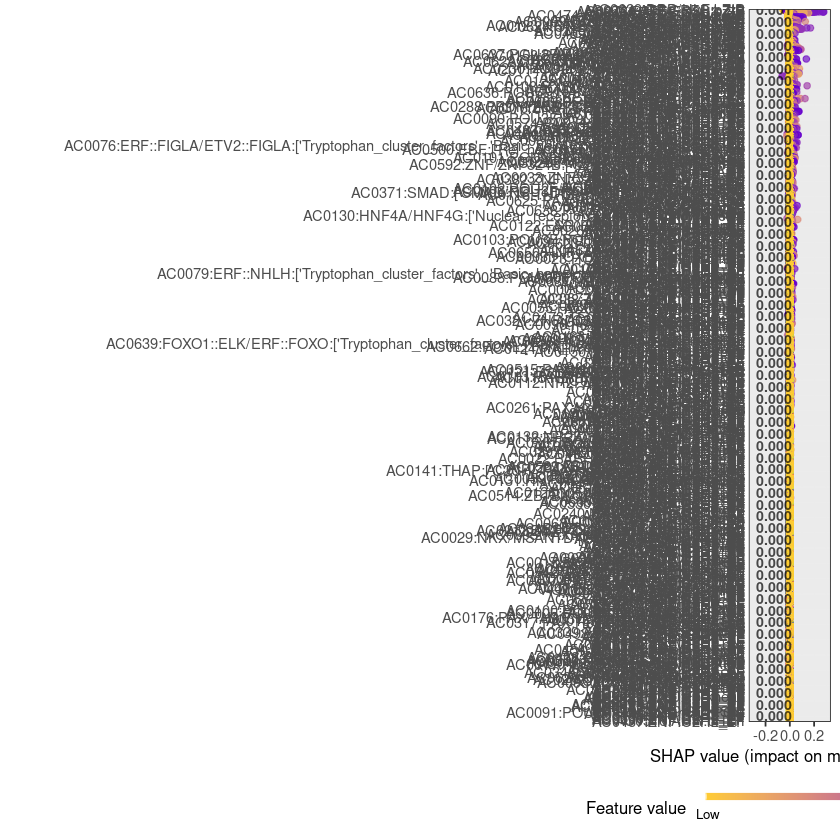

In [21]:
shap.plot.summary(shap_long)

In [22]:
feature_importance <- shap_values$mean_shap_score

imp_table <- tibble(
  Feature = names(feature_importance),
  Mean_SHAP = as.numeric(feature_importance)
) %>%
  arrange(desc(Mean_SHAP))

head(imp_table, 20)

Feature,Mean_SHAP
<chr>,<dbl>
AC0629:DBP/HLF:bZIP,1.378006e-03
AC0631:ATF/CREB:bZIP,5.927005e-04
AC0273:BATF/FOSL:bZIP,4.336167e-04
AC0450:ZBTB:C2H2_ZF,3.062898e-04
AC0048:NFE2L/JUN:bZIP,2.040721e-04
AC0474:GRHL/TFCP:Grainyhead,1.888572e-04
AC0651:ZNF:C2H2_ZF,1.823237e-04
AC0270:FOXN:Forkhead,1.815799e-04
AC0179:ZNF:C2H2_ZF,1.561917e-04


`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -0.073028”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.0053331”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.073028”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.073028”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“zero-width neighborhood. make span bigger”
Warning message:
“Failed to fit group -1.
Caused by error in `predLoess()`:
! NA/NaN/Inf in for

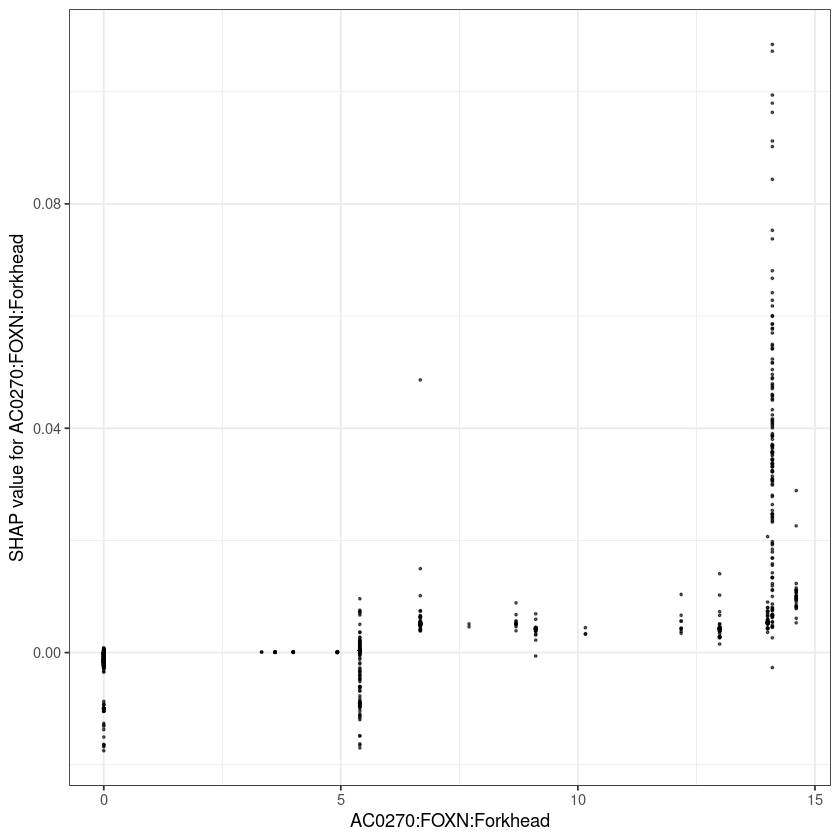

In [24]:
shap.plot.dependence(
  shap_long, 
  x = "AC0270:FOXN:Forkhead", 
  y = NULL
)

In [25]:
feature_importance <- tibble(
  Feature = names(shap_values$mean_shap_score),
  Mean_SHAP = as.numeric(shap_values$mean_shap_score)
) %>% arrange(desc(Mean_SHAP))

In [30]:
topk <- 30
top_features <- feature_importance$Feature[1:topk]
top_features

[1] "AC0629:DBP/HLF:bZIP"               "AC0631:ATF/CREB:bZIP"             
 [3] "AC0273:BATF/FOSL:bZIP"             "AC0450:ZBTB:C2H2_ZF"              
 [5] "AC0048:NFE2L/JUN:bZIP"             "AC0474:GRHL/TFCP:Grainyhead"      
 [7] "AC0651:ZNF:C2H2_ZF"                "AC0270:FOXN:Forkhead"             
 [9] "AC0179:ZNF:C2H2_ZF"                "AC0066:USF/BHLHE:bHLH"            
[11] "AC0628:CEBPB/CEBPE:bZIP"           "AC0009:DUXA/DUX:Homeodomain"      
[13] "AC0256:MAFF/MAF:bZIP"              "AC0344:ZKSCAN:C2H2_ZF"            
[15] "AC0342:YBX:CSD"                    "AC0123:NR1D/RORC:Nuclear_receptor"
[17] "AC0624:ONECUT:CUT,Homeodomain"     "AC0047:ZNF:C2H2_ZF"               
[19] "AC0272:GMEB:SAND"                  "AC0135:NR2E:Nuclear_receptor"     
[21] "AC0166:ZNF:C2H2_ZF"                "AC0633:CREB3L/XBP:bZIP"           
[23] "AC0459:SIX/ZNF:Homeodomain"        "AC0049:JUND/JUN:bZIP"             
[25] "AC0613:ZNF:C2H2_ZF"                "AC0267:MTF:Unknown"               
[27] "AC0668:STAT/ETV:STAT"              "AC0140:ZNF:C2H2_ZF"               
[29] "AC0046:BACH/NFE:bZIP"              "AC0269:FOXN:Forkhead"

In [37]:
shap_long_top <- shap_long %>% 
  filter(variable %in% top_features) %>%
   dplyr::mutate(variable = as.character(variable)) %>%
   dplyr::mutate(variable = factor(variable, levels = top_features))
shap_long_top

ID,variable,value,rfvalue,stdfvalue,mean_value
<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,AC0629:DBP/HLF:bZIP,0.15615489,6.198104,0.6958730,0.001378006
2,AC0629:DBP/HLF:bZIP,0.14079396,6.198104,0.6958730,0.001378006
3,AC0629:DBP/HLF:bZIP,0.12729721,6.198104,0.6958730,0.001378006
4,AC0629:DBP/HLF:bZIP,0.13108256,6.198104,0.6958730,0.001378006
5,AC0629:DBP/HLF:bZIP,0.23736531,4.409525,0.4950657,0.001378006
6,AC0629:DBP/HLF:bZIP,0.08001651,6.198104,0.6958730,0.001378006
7,AC0629:DBP/HLF:bZIP,0.11669888,6.198104,0.6958730,0.001378006
8,AC0629:DBP/HLF:bZIP,0.19144978,4.409525,0.4950657,0.001378006
9,AC0629:DBP/HLF:bZIP,0.19587044,6.198103,0.6958729,0.001378006


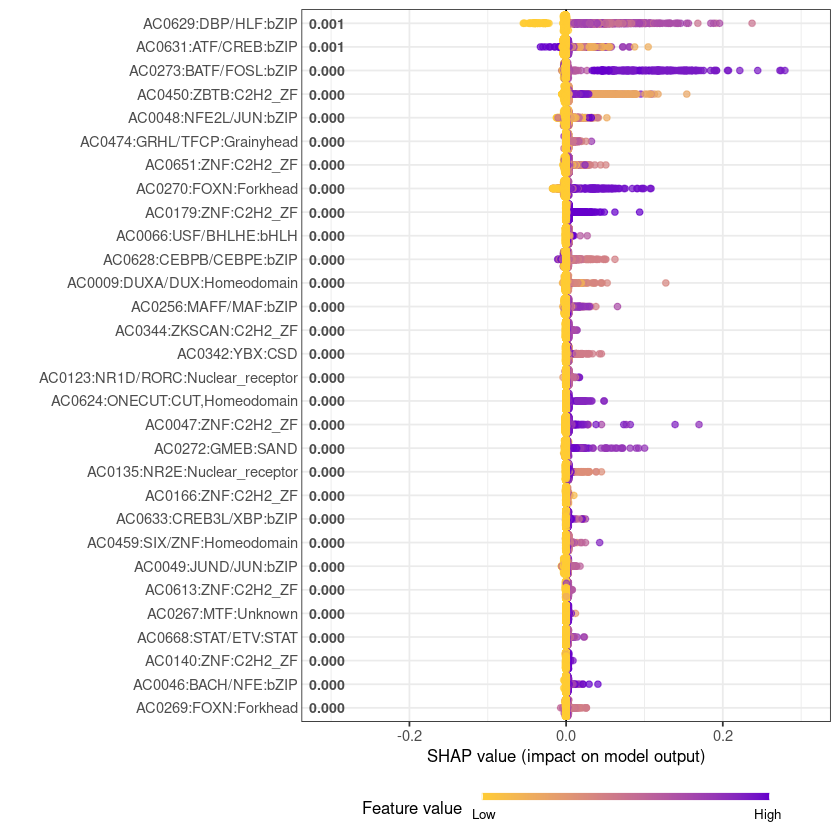

In [38]:
shap.plot.summary(shap_long_top)